Pola Kualitas Udara di Jakarta dari Januari 2010 - Februari 2025
Kelas B Kelompok 15
- Maghfur Nara (5027261129)
- Farras Ananda Pramana (5027261068)
- Ali Riza Alayubi (5027261020)
Smartcity
Air Quality Index in Jakarta - Daily Air Quality Index (AQI) in Jakarta from January 2010 - February 2025

Jakarta adalah salah satu kota dengan kualitas udara yang sering menjadi sorotan, karena padatnya kendaraan bermotor, aktivitas industri, dan pembangkit listrik di sekitarnya. Dataset Daily Air Quality Index (AQI) in Jakarta mencatat nilai AQI harian dari Januari 2010 sampai Februari 2025, sehingga rentang waktunya lebih dari satu dekade. Data sepanjang itu memungkinkan kita melihat seberapa buruk kualitas udara Jakarta dari waktu ke waktu, apakah ada pola musiman, dan apakah kondisinya membaik atau memburuk. Hasilnya penting karena kualitas udara berkaitan langsung dengan kesehatan warga, sehingga pola yang kita temukan bisa menjadi dasar untuk memahami kapan udara Jakarta paling berisiko.

1. Berapa rata-rata, median, dan seberapa besar variasi (standar deviasi) AQI Jakarta per bulan?
2. Bulan apa yang rata-rata AQI paling tinggi dan paling rendah, dan apakah ada pola musiman?
3. Bagaimana perubahan rata-rata AQI dari tahun ke tahun (2010–2025), dan tahun mana yang paling buruk?

In [1]:
import pandas as pd

df = pd.read_csv("Data/Dataset_AQJKT.csv") # Memuat dataset csv dari folder data
print('Ukuran dataset: %d baris dan %d kolom\n' % df.shape)
display(df.head())  # Memuat 5 baris dataset dari folder data
print("Penjelasan: Setiap baris mewakili satu catatan instans operasional atau tugas tunggal di pusat data.\n") #Jelaskan secara singkat: setiap baris mewakili apa? 

Ukuran dataset: 5538 baris dan 10 kolom



,tanggal,stasiun,pm25,pm10,so2,co,o3,no2,max,critical
0,2010-01-01,DKI1 (Bunderan HI),NaN,60.0,4.0,73.0,27.0,14.0,73.0,CO
1,2010-01-02,DKI1 (Bunderan HI),NaN,32.0,2.0,16.0,33.0,9.0,33.0,O3
2,2010-01-03,DKI1 (Bunderan HI),NaN,27.0,2.0,19.0,20.0,9.0,27.0,PM10
3,2010-01-04,DKI1 (Bunderan HI),NaN,22.0,2.0,16.0,15.0,6.0,22.0,PM10
4,2010-01-05,DKI1 (Bunderan HI),NaN,25.0,2.0,17.0,15.0,8.0,25.0,PM10


Penjelasan: Setiap baris mewakili satu catatan instans operasional atau tugas tunggal di pusat data.



SUMBER DATA
Kaggle, Air Quality Index in Jakarta (Taufiq Pohan, Daily Air Quality Index (AQI) in Jakarta from January 2010 - February 2025) "https://www.kaggle.com/datasets/senadu34/air-quality-index-in-jakarta-2010-2021"

Lisensi: Database Contents License (DbCL) v1.0 "https://opendatacommons.org/licenses/dbcl/1-0/"

Dataset ini memuat data Air Quality Index (AQI) atau Indeks Standar Pencemaran Udara (ISPU) yang diukur dari 5 stasiun pemantau kualitas udara 
(SPKU) di DKI Jakarta dari bulan Januari 2010 hingga Februari 2025. Data ini bersumber dari Satu Data Jakarta(https://satudata.jakarta.go.id/searchq=ispu&halaman=all&kategori=dataset&topik=all&organisasi=all&status=all&sort=desc&page_no=1&show_filter=true&lang=id).

JUMLAH BARIS: 5538
JUMLAH KOLOM: 10
Kamus Data:

| Kolom | Arti / Deskripsi | Jenis Variabel | Satuan |
|---|---|---|---|
| `tanggal` | Tanggal pencatatan kualitas udara | Kategorial (Interval/Waktu) | Tanggal |
| `stasiun` | Lokasi stasiun pemantauan kualitas udara | Kategorial (Nominal) | — |
| `pm25` | Konsentrasi partikulat udara berukuran ≤ 2,5 mikrometer | Numerik (Rasio) | µg/m³ |
| `pm10` | Konsentrasi partikulat udara berukuran ≤ 10 mikrometer | Numerik (Rasio) | µg/m³ |
| `so2` | Konsentrasi sulfur dioksida di udara | Numerik (Rasio) | µg/m³ |
| `co` | Konsentrasi karbon monoksida di udara | Numerik (Rasio) | µg/m³ |
| `o3` | Konsentrasi ozon di udara | Numerik (Rasio) | µg/m³ |
| `no2` | Konsentrasi nitrogen dioksida di udara | Numerik (Rasio) | µg/m³ |
| `max` | Nilai maksimum indeks kualitas udara pada hari tersebut | Numerik (Rasio) | ISPU |
| `critical` | Parameter pencemar yang menjadi parameter kritis/dominan | Kategorial (Nominal) | — |

In [2]:
df.info()                 # tipe data setiap kolom
print(df.isna().sum())           # jumlah data kosong per kolom
print(df.duplicated().sum())     # jumlah baris duplikat
print("Hasil temuan dari program di atas menunjukkan bahwa beberapa kolom memiliki kekosongan nilai\nDan keputusan yang akan kami lakukan adalah membiarkannya.\nKarena fokus kami di sini adalah untuk mencari rata-rata AQI dari nilai maxnya. Sedangkan nilai max yang kosong hanya 1. \nHal ini akan berpengaruh sangat kecil pada persentase akhirnya.")

<class 'pandas.DataFrame'>
RangeIndex: 5538 entries, 0 to 5537
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tanggal   5538 non-null   str    
 1   stasiun   5537 non-null   str    
 2   pm25      1516 non-null   float64
 3   pm10      5223 non-null   float64
 4   so2       5408 non-null   float64
 5   co        5450 non-null   float64
 6   o3        5434 non-null   float64
 7   no2       5432 non-null   float64
 8   max       5537 non-null   float64
 9   critical  5534 non-null   str    
dtypes: float64(7), str(3)
memory usage: 432.8 KB
tanggal        0
stasiun        1
pm25        4022
pm10         315
so2          130
co            88
o3           104
no2          106
max            1
critical       4
dtype: int64
0
Hasil temuan dari program di atas menunjukkan bahwa beberapa kolom memiliki kekosongan nilai
Dan keputusan yang akan kami lakukan adalah membiarkannya.
Karena fokus kami di sini adalah untuk mencari ra

In [15]:
kolom = df["pm25"]
print(kolom.mean(), kolom.median(), kolom.mode()[0])
print(kolom.var(), kolom.std()) #standard deviation
print(kolom.quantile(0.25), kolom.quantile(0.75))
df.describe()
print("PM25 memiliki nilai mean 89.742084 mikrogram/meter kubik dan median 90 mikrogram/meter kubik. Karena mean dan mediannya kurang lebih sama, maka bentuk sebaran datanya normal")
print("PM10 memiliki nilai mean 56.407046 mikrogram/meter kubik dan median 57 mikrogram/meter kubik. Karena mean dan mediannya kurang lebih sama, maka bentuk sebaran datanya normal")
print("O3/Ozon memiliki nilai mean 77.465771 mikrogram/meter kubik dan median 69 mikrogram/meter kubik. Karena meannya lebih dari median, artinya bentuk sebaran data dari O3 adalah positifly skewed/puncak tinggi baru turun melandai kearah kanan")


89.74208443271768 90.0 93.0
708.4093432430313 26.615960310366997
71.0 107.0
PM25 memiliki nilai mean 89.742084 mikrogram/meter kubik dan median 90 mikrogram/meter kubik. Karena mean dan mediannya kurang lebih sama, maka bentuk sebaran datanya normal
PM10 memiliki nilai mean 56.407046 mikrogram/meter kubik dan median 57 mikrogram/meter kubik. Karena mean dan mediannya kurang lebih sama, maka bentuk sebaran datanya normal
O3/Ozon memiliki nilai mean 77.465771 mikrogram/meter kubik dan median 69 mikrogram/meter kubik. Karena meannya lebih dari median, artinya bentuk sebaran data dari O3 adalah positifly skewed/puncak tinggi baru turun melandai kearah kanan


In [4]:
sampel = df["pm25"].dropna().head(10)

print("\nMean   :", sampel.mean())
print("Varians  :", sampel.var())
print("Std      :", sampel.std())
#print("apakah sama dengan hitung manual dengan rumus?")
#data_10awal = [58, 86, 93, 49, 89, 60, 50, 55, 67, 39]
#rata2 = sum(data_10awal) / 10
#print(rata2)


Mean   : 64.6
Varians  : 348.26666666666665
Std      : 18.661904154363956


In [5]:
df["critical"].value_counts()
df["critical"].value_counts(normalize=True) * 100

critical
O3      53.668233
PM25    25.460788
PM10    17.058186
SO2      1.861222
CO       1.499819
NO2      0.451753
Name: proportion, dtype: float64

In [6]:
df["stasiun"].value_counts()
df["stasiun"].value_counts(normalize=True) * 100

stasiun
DKI4 (Lubang Buaya)     30.232978
DKI2 (Kelapa Gading)    20.534586
DKI3 (Jagakarsa)        20.155319
DKI5 (Kebon Jeruk)      19.487087
DKI1 (Bunderan HI)       9.590031
Name: proportion, dtype: float64

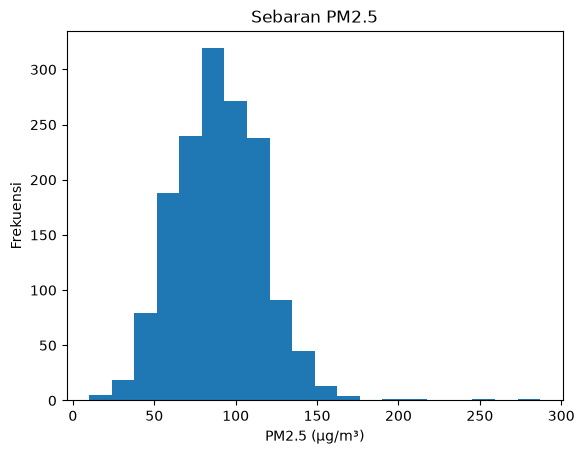

In [7]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(df["pm25"].dropna(), bins=20)
plt.title("Sebaran PM2.5")
plt.xlabel("PM2.5 (µg/m³)")
plt.ylabel("Frekuensi")
plt.show()

In [8]:
df.groupby("stasiun")["pm25"].median()

stasiun
DKI1 (Bunderan HI)      67.0
DKI2 (Kelapa Gading)    77.0
DKI3 (Jagakarsa)        69.0
DKI4 (Lubang Buaya)     99.0
DKI5 (Kebon Jeruk)      92.0
Name: pm25, dtype: float64

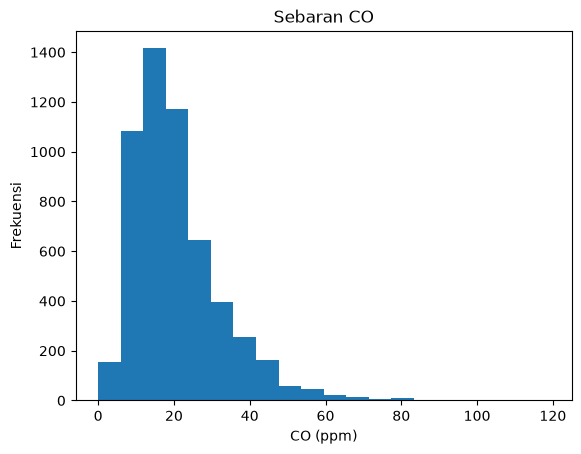

In [9]:
plt.figure()
plt.hist(df["co"].dropna(), bins=20)
plt.title("Sebaran CO")
plt.xlabel("CO (ppm)")
plt.ylabel("Frekuensi")
plt.show()

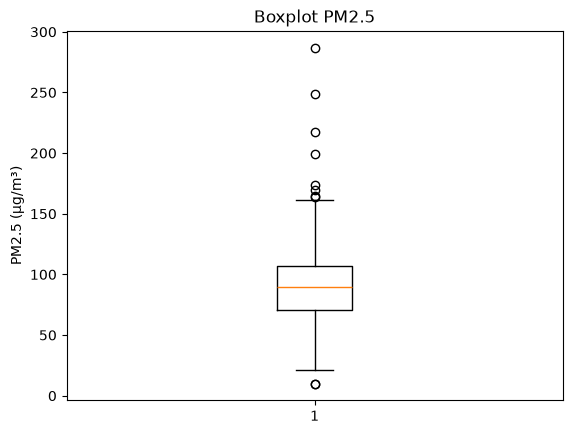

In [10]:
plt.figure()
plt.boxplot(df["pm25"].dropna())
plt.title("Boxplot PM2.5")
plt.ylabel("PM2.5 (µg/m³)")
plt.show()

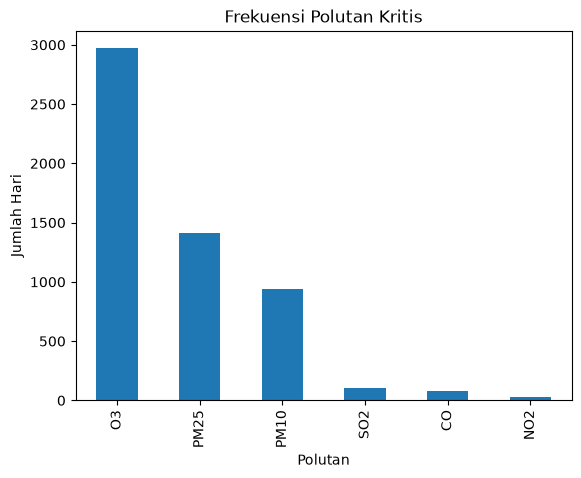

In [11]:
plt.figure()
df["critical"].value_counts().plot(kind="bar")
plt.title("Frekuensi Polutan Kritis")
plt.xlabel("Polutan")
plt.ylabel("Jumlah Hari")
plt.show()

MASI DRAFT BELUM FINAL KESIMPULANNYA

Kesimpulan  
[kesimpulan disini]
1. Berapa rata-rata, median, dan seberapa besar variasi (standar deviasi) AQI Jakarta per bulan?
        Rata-rata cenderung lebih tinggi daripada median di hampir semua bulan, artinya sebaran AQI bulanan sedikit miring ke kanan — ada beberapa  hari dengan AQI sangat tinggi yang menarik rata-rata ke atas. Variasi (std) paling besar terjadi di November (50,18), menandakan kualitas udara paling tidak menentu di bulan itu; std paling kecil ada di Mei (33,57) dan Juni (31,69), yang relatif lebih stabil.
2. Bulan apa yang rata-rata AQI paling tinggi dan paling rendah, dan apakah ada pola musiman?
        AQI paling tinggi: Oktober, dengan rata-rata 113,25.
        AQI paling rendah: Januari, dengan rata-rata 73,92.
3. Bagaimana perubahan rata-rata AQI dari tahun ke tahun (2010–2025), dan tahun mana yang paling buruk?
       Tahun terburuk: 2012, dengan rata-rata AQI 155,61 — jauh di atas tahun lain, dan standar deviasinya juga paling besar (64,01), menandakan fluktuasi harian ekstrem di tahun itu. Trennya tidak konsisten memburuk atau membaik, melainkan berfluktuasi naik-turun

- Tuliskan 3–5 temuan paling menarik
- Sebutkan keterbatasan data, misalnya periode yang pendek atau banyak data kosong
- Tuliskan ide pertanyaan lanjutan yang ingin kalian analisis nanti

In [12]:
df["tanggal"] = pd.to_datetime(df["tanggal"], errors="coerce")
df["bulan"] = df["tanggal"].dt.month
df["tahun"] = df["tanggal"].dt.year

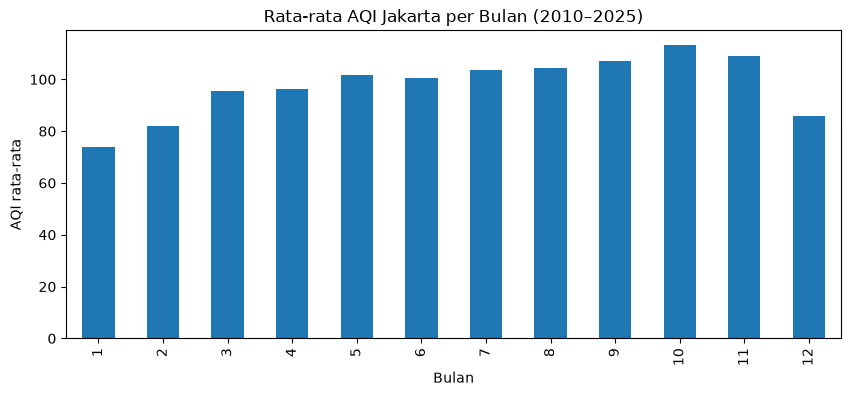

In [13]:
per_bulan = df.groupby("bulan")["max"].agg(["mean", "median", "std", "count"])
per_bulan["mean"].plot(kind="bar", figsize=(10,4))
plt.title("Rata-rata AQI Jakarta per Bulan (2010–2025)")
plt.xlabel("Bulan")
plt.ylabel("AQI rata-rata")
plt.show()

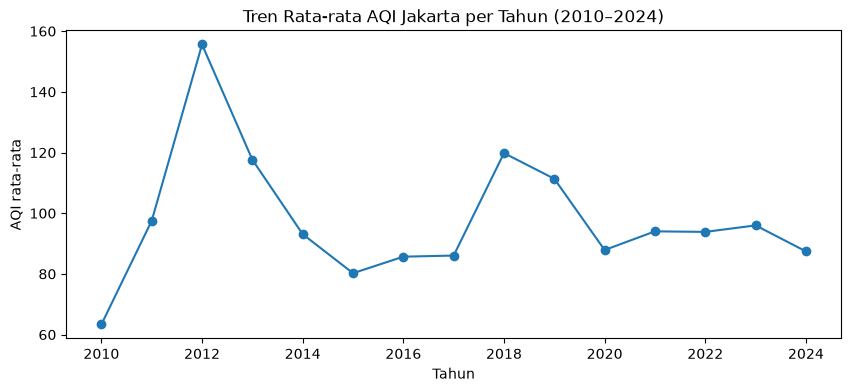

In [14]:
per_tahun = df.groupby("tahun")["max"].agg(["mean", "median", "std", "count"])
per_tahun.loc[2010:2024, "mean"].plot(kind="line", marker="o", figsize=(10,4))
plt.title("Tren Rata-rata AQI Jakarta per Tahun (2010–2024)")
plt.xlabel("Tahun")
plt.ylabel("AQI rata-rata")
plt.show()